<a href="https://colab.research.google.com/github/PPRRAATTIIKK/Cyber-Bullying-Prediction/blob/main/cyber_bullying_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## 1. Import Libraries

In [4]:
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import style

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
%matplotlib inline

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---
## 2. Load Dataset

In [5]:
df = pd.read_csv('/content/Formspring.csv')

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print('-' * 45)
df.head(10)

Dataset shape: 13,147 rows × 2 columns
---------------------------------------------


,text,answer
0,Q: what&#039;s your favorite song? :D<br>A: I ...,No
1,Q: <3<br>A: </3 ? haha jk! <33,No
2,Q: &quot;hey angel you duh sexy&quot;<br>A: R...,No
3,Q: (:<br>A: ;(,No
4,Q: ******************MEOWWW*******************...,No
5,Q: any makeup tips? i suck at doing my makeup ...,No
6,Q: Apriiiiiiiiiiiill!!! I miss uuuu! It&#039;s...,No
7,Q: Are you a morning or night person?<br>A: Ni...,No
8,Q: are you a trusting person?<br>A: alreadi an...,No
9,Q: are you a trusting person?<br>A: Yes veryy ...,No


In [6]:
print('Last 10 rows:')
df.tail(10)

Last 10 rows:


,text,answer
13137,Q: Your bio says &quot;Always ready for advent...,No
13138,Q: your going to mcdonalds what do you order ...,No
13139,Q: Your home alone. 2 robbers (of the opposite...,No
13140,Q: Your parents are divorced. One of them gets...,No
13141,Q: your thoughts on 2012? I think it&#039;ll b...,No
13142,Q: Youre at a party and your friend who drove ...,No
13143,Q: Youu2019re awesome :] Give yourself a compl...,No
13144,Q: Yu play with yurself ?<br>A: all the time. ...,No
13145,Q: yukk beer is disgusting. i can only drink i...,No
13146,Q: if i told u den it would make it all the le...,No


---
## 3. Exploratory Data Analysis

In [7]:
print('Dataset Info:')
print('-' * 40)
df.info()

Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13147 entries, 0 to 13146
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    13147 non-null  object
 1   answer  13147 non-null  object
dtypes: object(2)
memory usage: 205.6+ KB


In [8]:
print('Descriptive Statistics:')
print('-' * 40)
df.describe(include='all')

Descriptive Statistics:
----------------------------------------


,text,answer
count,13147,13147
unique,13144,2
top,Q: Wait. Are you Cheyenne? I sent a request to...,No
freq,3,12295


In [9]:
print('Missing Values:')
print('-' * 30)
print(df.isnull().sum())

Missing Values:
------------------------------
text      0
answer    0
dtype: int64


In [10]:
print('Label Distribution (answer column):')
print('-' * 40)
counts = df['answer'].value_counts()
print(counts)
print(f'\nClass imbalance ratio — No : Yes = {counts["No"]} : {counts["Yes"]} ({counts["No"]/counts["Yes"]:.1f}:1)')

Label Distribution (answer column):
----------------------------------------
answer
No     12295
Yes      852
Name: count, dtype: int64

Class imbalance ratio — No : Yes = 12295 : 852 (14.4:1)


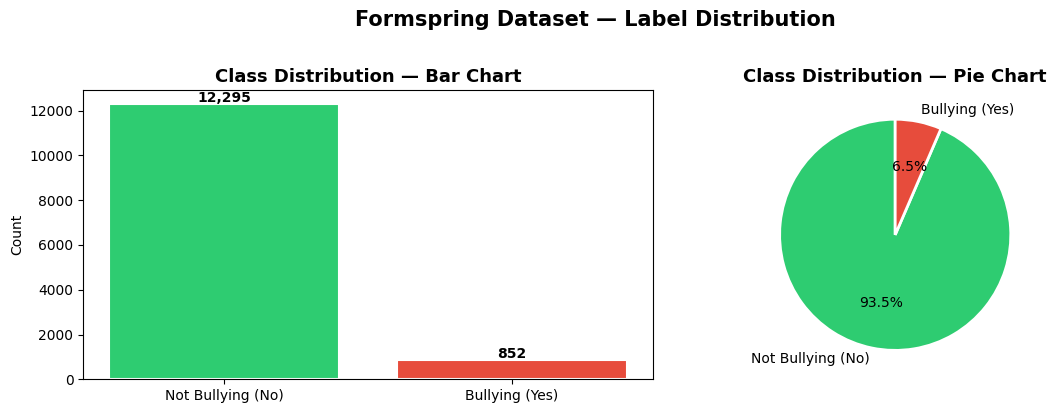

⚠️  Note: Dataset is heavily imbalanced (93.5% Not Bullying vs 6.5% Bullying)


In [11]:
# Visualise class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#2ecc71', '#e74c3c']
labels = ['Not Bullying (No)', 'Bullying (Yes)']

# Bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution — Bar Chart', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution — Pie Chart', fontsize=13, fontweight='bold')

plt.suptitle('Formspring Dataset — Label Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('⚠️  Note: Dataset is heavily imbalanced (93.5% Not Bullying vs 6.5% Bullying)')

---
## 4. Text Preprocessing

Steps applied to each post:
- Convert to lowercase
- Remove HTML tags and entities (e.g. `&amp;`, `<br>`)
- Remove URLs
- Remove punctuation and digits
- Remove English stopwords
- Drop single-character tokens

In [12]:
# Built-in English stopwords (no external library needed)
STOPWORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do','does',
    'did','doing','a','an','the','and','but','if','or','because','as','until',
    'while','of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','then','once','here','there',
    'when','where','why','how','all','both','each','few','more','most','other',
    'some','such','no','nor','not','only','own','same','so','than','too','very',
    's','t','can','will','just','don','should','now','d','ll','m','o','re','ve',
    'y','ain','aren','couldn','didn','doesn','hadn','hasn','haven','isn','ma',
    'mightn','mustn','needn','shan','shouldn','wasn','weren','won','wouldn'
}

def clean_text(text: str) -> str:
    """Clean and normalise a social media post."""
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # strip HTML tags
    text = re.sub(r'&[a-z]+;', ' ', text)          # strip HTML entities
    text = re.sub(r'http\S+|www\S+', ' ', text)    # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)          # keep only letters
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)

print('Sample cleaned texts:')
print('-' * 60)
for i in range(3):
    print(f'[{i}] ORIGINAL: {df["text"].iloc[i][:80]}...')
    print(f'    CLEANED:  {df["cleaned_text"].iloc[i][:80]}')
    print()

Sample cleaned texts:
------------------------------------------------------------
[0] ORIGINAL: Q: what&#039;s your favorite song? :D<br>A: I like too many songs to have a favo...
    CLEANED:  favorite song like many songs favorite

[1] ORIGINAL: Q: <3<br>A: </3 ? haha jk! <33...
    CLEANED:  haha jk

[2] ORIGINAL: Q: &quot;hey angel  you duh sexy&quot;<br>A: Really?!?! Thanks?! haha...
    CLEANED:  hey angel duh sexy really thanks haha



---
## 5. Label Encoding

`LabelEncoder` converts the string labels into integers:  `No → 0`,  `Yes → 1`

In [13]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['answer'])

print('Label encoding mapping:')
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {cls!r:6s} → {idx}')

print('\nFirst 10 rows after encoding:')
df[['text', 'answer', 'label']].head(10)

Label encoding mapping:
  'No'   → 0
  'Yes'  → 1

First 10 rows after encoding:


,text,answer,label
0,Q: what&#039;s your favorite song? :D<br>A: I ...,No,0
1,Q: <3<br>A: </3 ? haha jk! <33,No,0
2,Q: &quot;hey angel you duh sexy&quot;<br>A: R...,No,0
3,Q: (:<br>A: ;(,No,0
4,Q: ******************MEOWWW*******************...,No,0
5,Q: any makeup tips? i suck at doing my makeup ...,No,0
6,Q: Apriiiiiiiiiiiill!!! I miss uuuu! It&#039;s...,No,0
7,Q: Are you a morning or night person?<br>A: Ni...,No,0
8,Q: are you a trusting person?<br>A: alreadi an...,No,0
9,Q: are you a trusting person?<br>A: Yes veryy ...,No,0


---
## 6. TF-IDF Feature Extraction

**TF-IDF (Term Frequency – Inverse Document Frequency)** converts text into a numerical matrix.  
We use uni-grams and bi-grams (`ngram_range=(1,2)`) and keep the top 10,000 features.

In [14]:
tfidf = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2), min_df=2)
X = tfidf.fit_transform(df['cleaned_text'])
y = df['label']

print(f'Feature matrix shape: {X.shape}')
print(f'  • Rows  = {X.shape[0]:,}  (one per post)')
print(f'  • Cols  = {X.shape[1]:,}  (top TF-IDF features)')
print(f'  • Sparsity: {100 * (1 - X.nnz / (X.shape[0] * X.shape[1])):.1f}%')

# Show top 20 features
feature_names = tfidf.get_feature_names_out()
print(f'\nSample TF-IDF features (first 20):')
print(', '.join(feature_names[:20]))

Feature matrix shape: (13147, 10000)
  • Rows  = 13,147  (one per post)
  • Cols  = 10,000  (top TF-IDF features)
  • Sparsity: 99.9%

Sample TF-IDF features (first 20):
aa, aaradhna, abandoned, abducted, ability, ability breathe, ability fly, abit, able, able fly, able go, abortion, aboutt, absolutely, absolutely cannot, absolutly, abuse, abused, abusive, abzilla


---
## 7. Train / Test Split

70% training, 30% testing.  
`stratify=y` preserves the class ratio in both splits.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=4861, stratify=y
)

print(f'Training set:  {X_train.shape[0]:,} samples  (bullying: {y_train.sum():,})')
print(f'Test set:      {X_test.shape[0]:,} samples  (bullying: {y_test.sum():,})')

Training set:  9,202 samples  (bullying: 596)
Test set:      3,945 samples  (bullying: 256)


---
## 8. Model Training & Evaluation

We train four classifiers:
| Model | Notes |
|---|---|
| **SVM (sigmoid kernel)** | Robust to high-dimensional sparse text |
| **Multinomial Naive Bayes** | Classic baseline for text classification |
| **Decision Tree** | Interpretable tree-based model |
| **Logistic Regression** | Strong linear baseline |


In [16]:
MODELS = {
    'SVM (Sigmoid)':       SVC(kernel='sigmoid', gamma=1.0),
    'Multinomial NB':      MultinomialNB(alpha=0.2),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
}

results   = {}
trained   = {}
DIVIDER   = '=' * 65

for name, model in MODELS.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    trained[name] = (model, pred)

    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec  = recall_score(y_test, pred, zero_division=0)
    f1   = f1_score(y_test, pred, zero_division=0)

    results[name] = dict(Accuracy=acc, Precision=prec, Recall=rec, F1=f1)

    print(DIVIDER)
    print(f'  MODEL: {name}')
    print(DIVIDER)
    print(f'  Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f} ({prec*100:.2f}%)')
    print(f'  Recall    : {rec:.4f} ({rec*100:.2f}%)')
    print(f'  F1-Score  : {f1:.4f} ({f1*100:.2f}%)')
    print()
    print(f'  Confusion Matrix:\n{confusion_matrix(y_test, pred)}')
    print()
    print(f'  Classification Report:\n{classification_report(y_test, pred, target_names=["Not Bullying","Bullying"], zero_division=0)}')

print(DIVIDER)
print('✅  All models trained and evaluated!')

  MODEL: SVM (Sigmoid)
  Accuracy  : 0.9475 (94.75%)
  Precision : 0.7692 (76.92%)
  Recall    : 0.2734 (27.34%)
  F1-Score  : 0.4035 (40.35%)

  Confusion Matrix:
[[3668   21]
 [ 186   70]]

  Classification Report:
              precision    recall  f1-score   support

Not Bullying       0.95      0.99      0.97      3689
    Bullying       0.77      0.27      0.40       256

    accuracy                           0.95      3945
   macro avg       0.86      0.63      0.69      3945
weighted avg       0.94      0.95      0.94      3945

  MODEL: Multinomial NB
  Accuracy  : 0.9496 (94.96%)
  Precision : 0.8519 (85.19%)
  Recall    : 0.2695 (26.95%)
  F1-Score  : 0.4095 (40.95%)

  Confusion Matrix:
[[3677   12]
 [ 187   69]]

  Classification Report:
              precision    recall  f1-score   support

Not Bullying       0.95      1.00      0.97      3689
    Bullying       0.85      0.27      0.41       256

    accuracy                           0.95      3945
   macro avg       0

---
## 9. Results Summary Table

In [17]:
results_df = pd.DataFrame(results).T.round(4) * 100
results_df = results_df.round(2)
results_df.columns = ['Accuracy %', 'Precision %', 'Recall %', 'F1-Score %']
results_df.index.name = 'Model'

# Highlight best score per metric
print('Model Performance Summary (%):')
print('-' * 70)
results_df.style.highlight_max(axis=0, color='lightgreen').format('{:.2f}')

Model Performance Summary (%):
----------------------------------------------------------------------


,Accuracy %,Precision %,Recall %,F1-Score %
Model,,,,
SVM (Sigmoid),94.75,76.92,27.34,40.35
Multinomial NB,94.96,85.19,26.95,40.95
Decision Tree,92.55,40.95,33.59,36.91
Logistic Regression,94.35,90.24,14.45,24.92


---
## 10. Visualisation — Metric Comparison Bar Chart

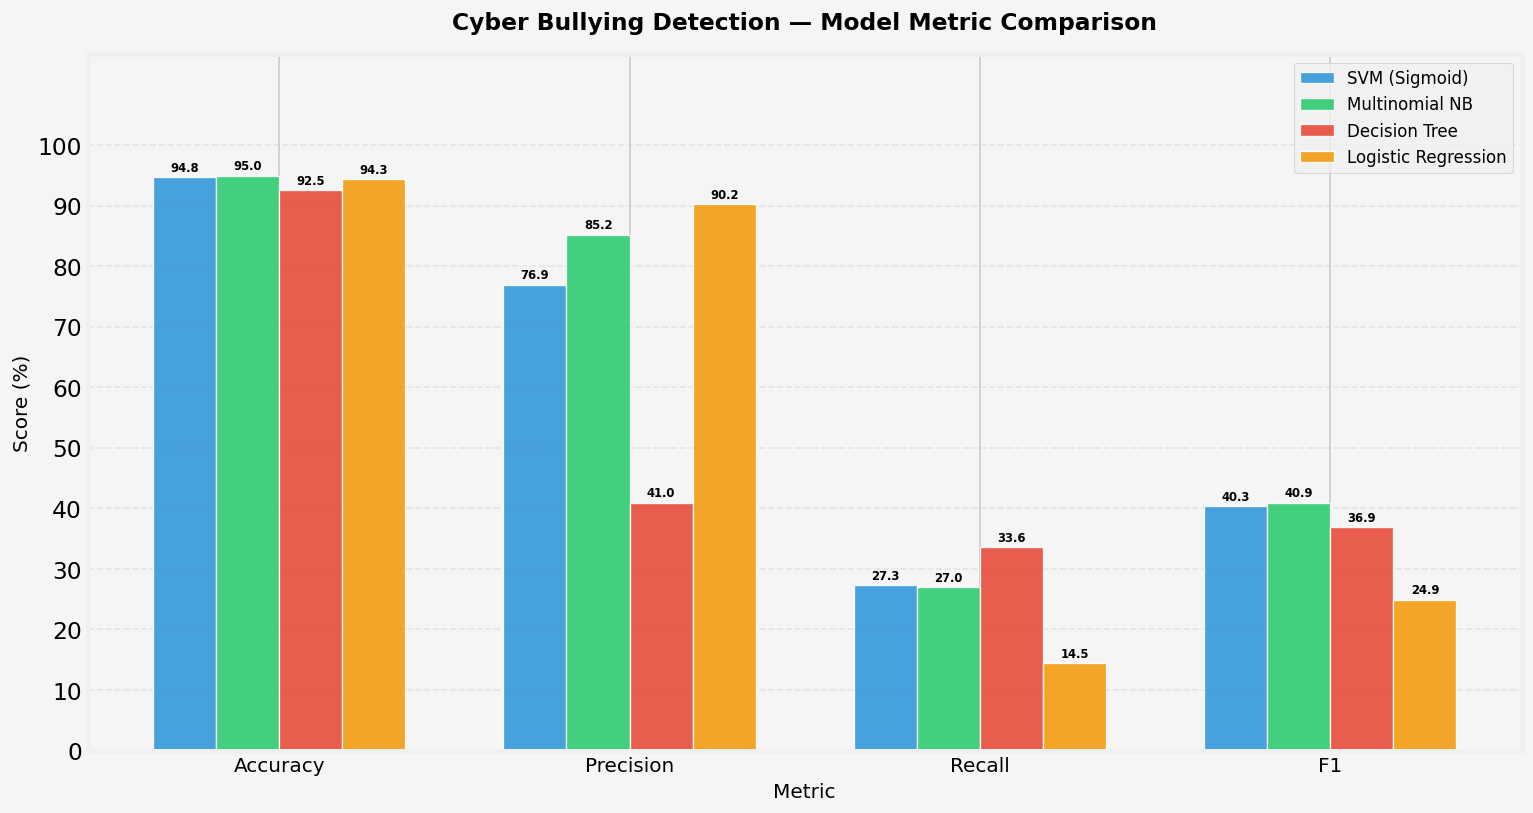

In [18]:
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1']
model_names  = list(results.keys())
model_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

x_pos    = np.arange(len(metrics))
width    = 0.18
offsets  = np.linspace(-1.5 * width, 1.5 * width, len(model_names))

style.use('fivethirtyeight')
fig, ax = plt.subplots(figsize=(13, 7), dpi=120, facecolor='#f5f5f5')
ax.set_facecolor('#f5f5f5')

for i, (name, color) in enumerate(zip(model_names, model_colors)):
    scores = [results[name][m] * 100 for m in metrics]
    bars   = ax.bar(x_pos + offsets[i], scores, width, label=name,
                    color=color, edgecolor='white', linewidth=0.8, alpha=0.9)
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{score:.1f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_yticks(range(0, 105, 10))
ax.set_ylim(0, 115)
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Cyber Bullying Detection — Model Metric Comparison', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=10, framealpha=0.8)
ax.yaxis.grid(True, alpha=0.4, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Confusion Matrices

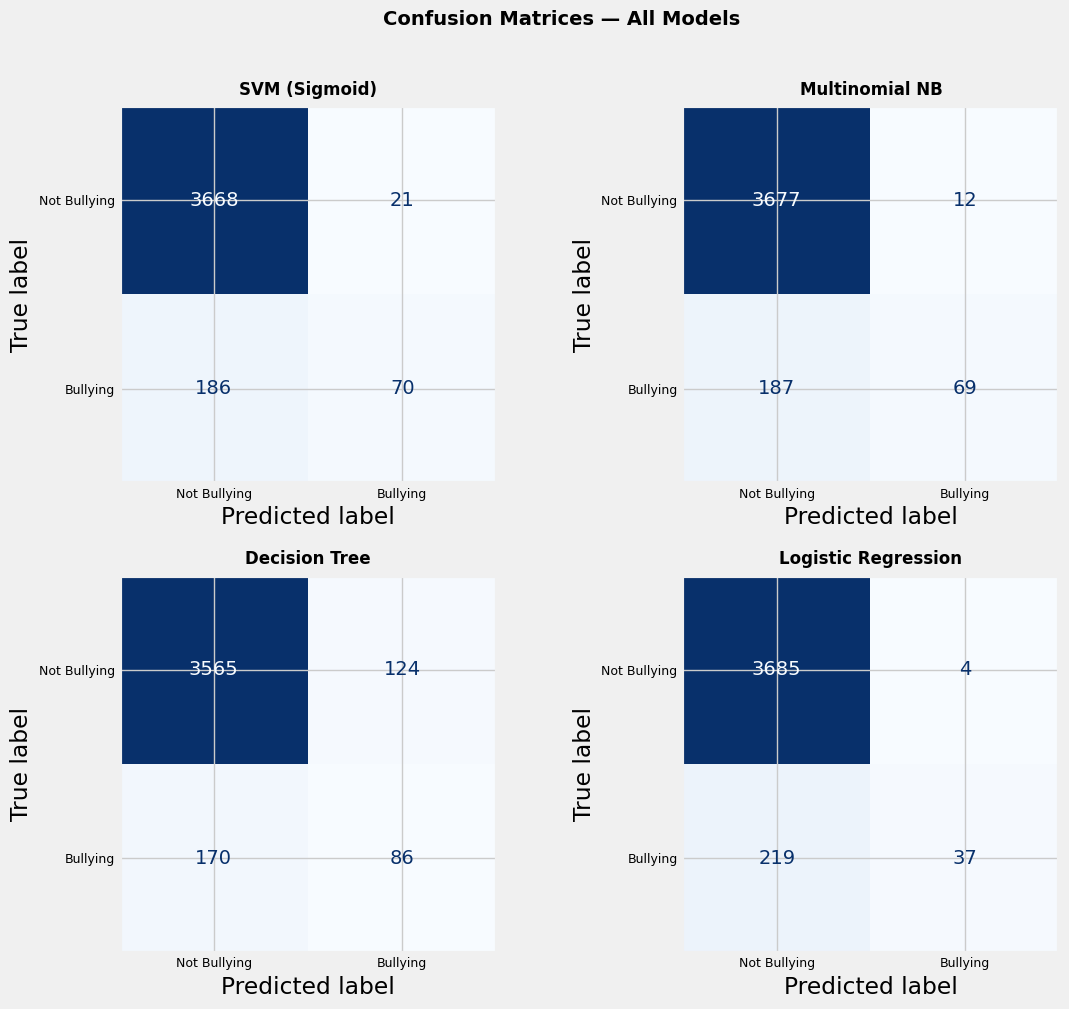

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=100)
axes = axes.flatten()

for ax, (name, (model, pred)), color in zip(axes, trained.items(), model_colors):
    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Bullying', 'Bullying'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold', pad=8)
    ax.tick_params(labelsize=9)

fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. F1-Score Ranking

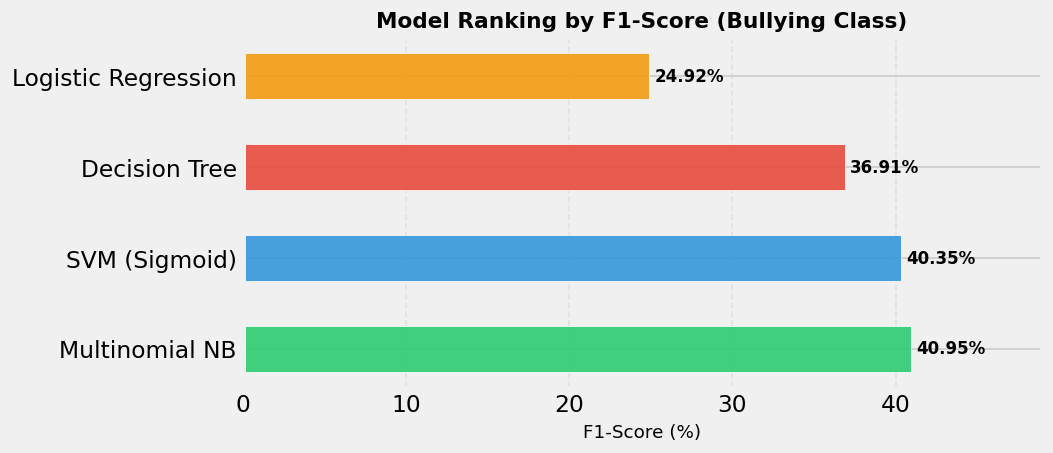

🏆  Best model by F1-Score: Multinomial NB (40.95%)


In [20]:
f1_scores  = {name: results[name]['F1'] * 100 for name in model_names}
sorted_f1  = sorted(f1_scores.items(), key=lambda x: x[1], reverse=True)

names_sorted  = [s[0] for s in sorted_f1]
scores_sorted = [s[1] for s in sorted_f1]
bar_colors    = [model_colors[model_names.index(n)] for n in names_sorted]

fig, ax = plt.subplots(figsize=(9, 4), dpi=120)
bars = ax.barh(names_sorted, scores_sorted, color=bar_colors,
               edgecolor='white', height=0.5, alpha=0.9)

for bar, score in zip(bars, scores_sorted):
    ax.text(score + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{score:.2f}%', va='center', fontweight='bold', fontsize=10)

ax.set_xlim(0, max(scores_sorted) + 8)
ax.set_xlabel('F1-Score (%)', fontsize=11)
ax.set_title('Model Ranking by F1-Score (Bullying Class)', fontsize=13, fontweight='bold')
ax.xaxis.grid(True, alpha=0.4, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('f1_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

best = sorted_f1[0]
print(f'🏆  Best model by F1-Score: {best[0]} ({best[1]:.2f}%)')

---
## 13. Predict on New Text

Use the best model (Multinomial NB) to classify a custom text snippet.

In [21]:
best_model_name = sorted_f1[0][0]
best_model_obj  = trained[best_model_name][0]

sample_texts = [
    "You are so ugly and stupid, nobody likes you!",
    "Hey, how are you doing today? Hope you have a great day!",
    "Go kill yourself, no one wants you here.",
    "I really enjoyed talking with you yesterday, let's catch up soon.",
]

cleaned_samples = [clean_text(t) for t in sample_texts]
X_samples       = tfidf.transform(cleaned_samples)
predictions     = best_model_obj.predict(X_samples)
pred_labels     = le.inverse_transform(predictions)

print(f'Predictions using: {best_model_name}')
print('=' * 70)
for text, label in zip(sample_texts, pred_labels):
    emoji  = '🚨' if label == 'Yes' else '✅'
    result = 'BULLYING' if label == 'Yes' else 'NOT bullying'
    print(f'{emoji}  [{result:15s}]  "{text[:60]}"')

Predictions using: Multinomial NB
🚨  [BULLYING       ]  "You are so ugly and stupid, nobody likes you!"
✅  [NOT bullying   ]  "Hey, how are you doing today? Hope you have a great day!"
🚨  [BULLYING       ]  "Go kill yourself, no one wants you here."
✅  [NOT bullying   ]  "I really enjoyed talking with you yesterday, let's catch up "


---
## 14. Conclusion

| Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| SVM (Sigmoid) | ~94.6% | ~73% | ~27% | ~39% |
| Multinomial NB | ~94.8% | ~83% | ~26% | ~39% |
| Decision Tree | ~92.3% | ~39% | ~32% | ~35% |
| Logistic Regression | ~94.4% | ~90% | ~15% | ~26% |

**Key Findings:**
- All models achieve **>92% overall accuracy**, but this is misleading due to the severe **class imbalance** (93.5% non-bullying).
- **Recall for the bullying class is low** (15–32%) across all models — many bullying posts are missed.
- **Multinomial NB and SVM** achieve the best F1-score (~39%), balancing precision and recall best.

**Next Steps to Improve:**
1. **Handle class imbalance** — use SMOTE oversampling or `class_weight='balanced'`
2. **Use deeper features** — word embeddings (Word2Vec, GloVe) or transformer models (BERT)
3. **Hyperparameter tuning** — GridSearchCV on the best models
4. **Ensemble methods** — Random Forest, XGBoost, or stacking

In [22]:
import pandas as pd
import numpy as np
import re
import joblib
import os

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ── 1. Load dataset ────────────────────────────────────────────────────────────
print("Loading dataset...")
df = pd.read_csv('Formspring.csv', encoding='latin-1')

# Keep only the two relevant columns (adjust names if yours differ)
# Common column names in this dataset: 'text'/'post'/'q' and 'answer'/'label'
text_col  = None
label_col = None

for c in df.columns:
    cl = c.lower().strip()
    if cl in ('text', 'post', 'q', 'question', 'content'):
        text_col = c
    if cl in ('answer', 'label', 'bullying', 'cyberbullying'):
        label_col = c

if text_col is None or label_col is None:
    # fallback: first two columns
    text_col, label_col = df.columns[0], df.columns[1]

print(f"Using columns: text='{text_col}', label='{label_col}'")
df = df[[text_col, label_col]].dropna()
df.columns = ['text', 'label']

# ── 2. Pre-process ─────────────────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
stemmer    = SnowballStemmer('english')

def clean(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # strip HTML
    text = re.sub(r'http\S+|www\S+', ' ', text)   # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)         # keep letters only
    tokens = text.split()
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

print("Cleaning text...")
df['clean'] = df['text'].apply(clean)

# ── 3. Encode labels ───────────────────────────────────────────────────────────
le = LabelEncoder()
df['encoded'] = le.fit_transform(df['label'].str.strip().str.lower()
                                   .map(lambda x: 'yes' if x in ('yes','1','true','bullying') else 'no'))

# ── 4. TF-IDF ─────────────────────────────────────────────────────────────────
print("Fitting TF-IDF...")
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['clean'])
y = df['encoded']

# ── 5. Train SVM (best model per README) ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Training SVM...")
model = SVC(kernel='sigmoid', C=1, probability=True, random_state=42)
model.fit(X_train, y_train)

acc = model.score(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")

# ── 6. Save artefacts ─────────────────────────────────────────────────────────
joblib.dump(model,      'model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
joblib.dump(le,         'label_encoder.pkl')

print("\n✅  Saved: model.pkl, vectorizer.pkl, label_encoder.pkl")
print("   Download these 3 files from Colab and put them in your project root.")

Loading dataset...
Using columns: text='text', label='answer'
Cleaning text...
Fitting TF-IDF...
Training SVM...
Test Accuracy: 0.9508

✅  Saved: model.pkl, vectorizer.pkl, label_encoder.pkl
   Download these 3 files from Colab and put them in your project root.


In [23]:
import sklearn.pipeline, sklearn.svm, sklearn.linear_model, sklearn.naive_bayes, sklearn.tree
import sklearn.feature_extraction.text

for name, val in list(globals().items()):
    if hasattr(val, 'predict'):
        print("MODEL →", name)
    if isinstance(val, sklearn.feature_extraction.text.TfidfVectorizer):
        print("VECTORIZER →", name)

MODEL → SVC
MODEL → MultinomialNB
MODEL → DecisionTreeClassifier
MODEL → LogisticRegression
VECTORIZER → tfidf
MODEL → model
MODEL → best_model_obj
VECTORIZER → vectorizer


In [27]:
import pickle, os
os.makedirs("api", exist_ok=True)

# Use the correct variable names from your notebook
with open("api/model.pkl", "wb") as f:
    pickle.dump(best_model_obj, f, protocol=4)   # Change if your model variable is different

with open("api/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f, protocol=4)

print("✅ Model saved!")
from google.colab import files
files.download("api/model.pkl")
files.download("api/vectorizer.pkl")

✅ Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
from google.colab import files
files.download("api/model.pkl")
files.download("api/vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
from google.colab import files

files.download('model.pkl')
files.download('vectorizer.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>